Judul: Klasifikasi kain defektif dan kain non defektif menggunakan fitur GLCM dengan membandingkan teknik preprocessing.
Percobaan 1 (Resize + Grayscale)
Nama Anggota: Deswita Salsabila (F1D02410004)
Nama Anggota: Winona Andien Jihan Habbibah (F1D02410027)
Nama Anggota: Faiz Ahmad Tsaqib Wirawan (F1D02410043)
Nama Anggota: Dita Ayu Julita (F1D02410111)

Pada percobaan pertama, preprocessing yang digunakan adalah Resize dan Grayscale sebagai baseline. Tujuannya adalah melihat awal proses tanpa preprocessing khusus, sehingga hasilnya dapat dijadikan pembanding untuk percobaan selanjutnya. Resize digunakan untuk menyeragamkan ukuran seluruh citra, sedangkan Grayscale agar intensitas warna menjadi abu-abu untuk memudahkan proses selanjutnya.

In [2]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

DATA LOADING

In [3]:
data = []
labels = []
file_name = []

TARGET_SIZE = (128, 128)
DATASET_PATH = "dataset"

for sub_folder in os.listdir(DATASET_PATH):
    sub_folder_path = os.path.join(DATASET_PATH, sub_folder)
    if not os.path.isdir(sub_folder_path):
        continue
    for filename in os.listdir(sub_folder_path):
        img_path = os.path.join(sub_folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = img.astype(np.uint8)
        img = cv.resize(img, TARGET_SIZE)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f"Total data: {len(data)}")
print(f"Label unik: {np.unique(labels)}")

Total data: 170
Label unik: ['defect' 'non_defect']


DATA UNDERSTANDING

Distribusi data:
  defect: 85 gambar
  non_defect: 85 gambar


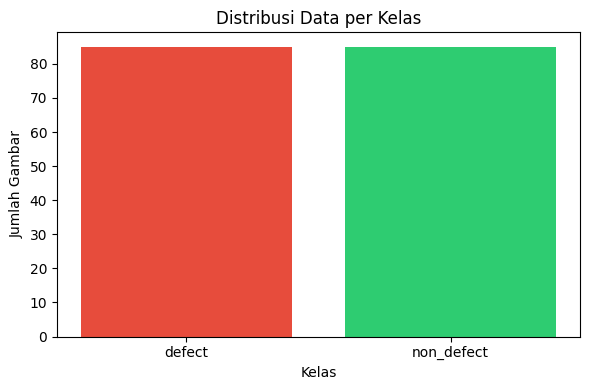

In [4]:
unique, counts = np.unique(labels, return_counts=True)
print("Distribusi data:")
for u, c in zip(unique, counts):
    print(f"  {u}: {c} gambar")

plt.figure(figsize=(6, 4))
plt.bar(unique, counts, color=['#e74c3c', '#2ecc71'])
plt.title('Distribusi Data per Kelas')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.tight_layout()
plt.show()

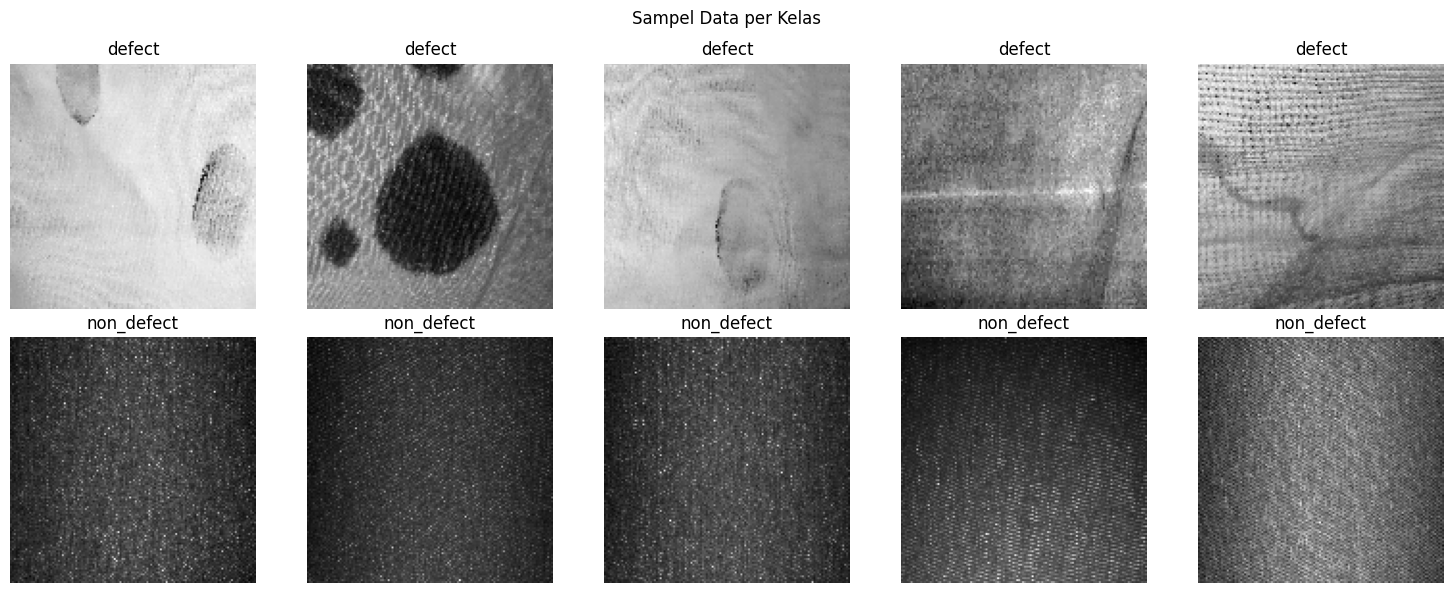

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, label in enumerate(unique):
    indices = np.where(labels == label)[0]
    for j in range(5):
        axes[idx][j].imshow(data[indices[j]], cmap='gray')
        axes[idx][j].set_title(f'{label}')
        axes[idx][j].axis('off')
plt.suptitle('Sampel Data per Kelas')
plt.tight_layout()
plt.show()

Dataset yang digunakan terdiri dari 170 citra kain, dengan 85 citra kelas defect dan 85 citra kelas non_defect. Jumlah data antar kelas sudah seimbang sehingga tidak diperlukan augmentasi data.

Terlihat bahwa kelas defect memiliki area cacat berupa bintik atau bercak gelap yang kontras dengan tekstur kain di sekitarnya, serta beberapa citra menunjukkan garis horizontal yang memperlihatkan kerusakan pada serat kain. Sementara itu, kelas non_defect menunjukkan tekstur kain yang lebih bagus tanpa adanya bercak.

DATA AUGMENTATION

In [6]:
print(f"Total data: {len(data)}")
print("Augmentasi tidak diperlukan karena jumlah data sudah mencukupi.")

Total data: 170
Augmentasi tidak diperlukan karena jumlah data sudah mencukupi.


DATA PREPARATION & DEFINE PREPROCESSING FUNCTION

In [7]:
def resize(image, target_size):
    return cv.resize(image, target_size)

def prepro1(image):
    """
    Percobaan 1 - Baseline
    Preprocessing: Resize + Grayscale
    Grayscale sudah dilakukan saat load data.
    Fungsi ini memastikan tipe data uint8.
    """
    return image.astype(np.uint8)

PREPROCESSING

In [8]:
dataPreprocessed = []
for i in range(len(data)):
    processed = prepro1(data[i])
    dataPreprocessed.append(processed)

dataPreprocessed = np.array(dataPreprocessed)
print(f"Shape data setelah preprocessing: {dataPreprocessed.shape}")

Shape data setelah preprocessing: (170, 128, 128)


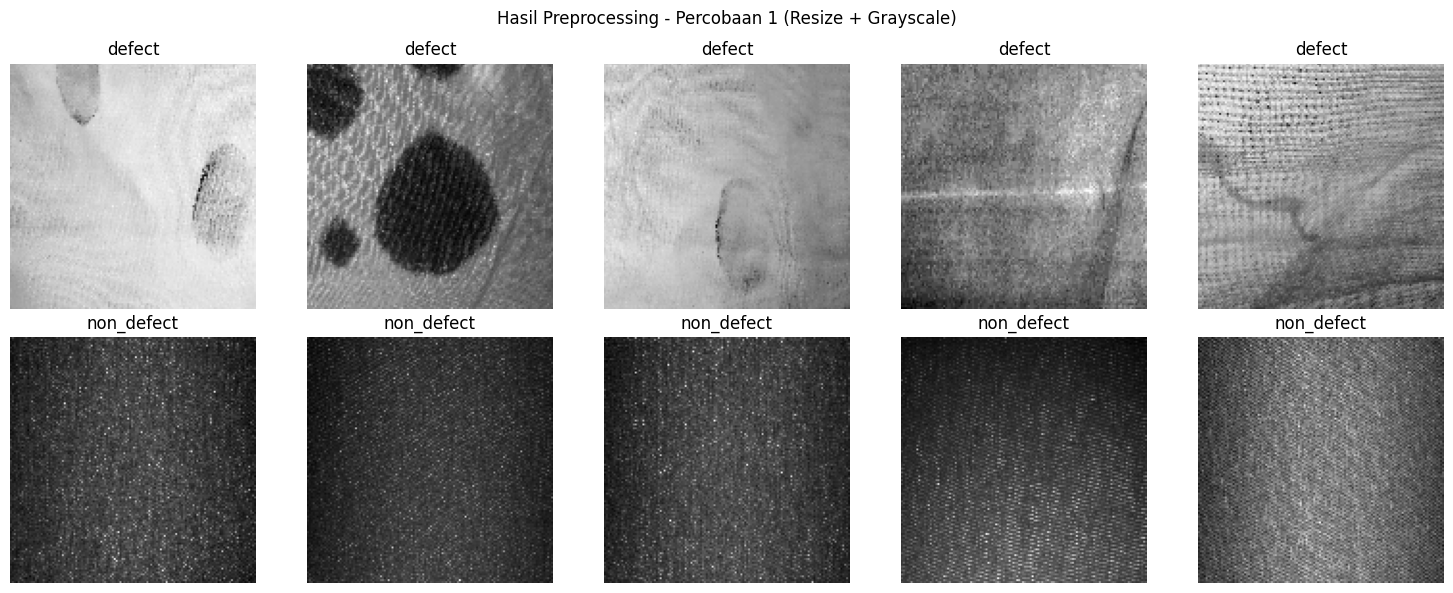

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, label in enumerate(unique):
    indices = np.where(labels == label)[0]
    for j in range(5):
        axes[idx][j].imshow(dataPreprocessed[indices[j]], cmap='gray')
        axes[idx][j].set_title(f'{label}')
        axes[idx][j].axis('off')
plt.suptitle('Hasil Preprocessing - Percobaan 1 (Resize + Grayscale)')
plt.tight_layout()
plt.show()

FEATURE EXTRACTION

In [10]:
def glcm(image, derajat, distance=1):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut harus salah satu dari: 0, 45, 90, 135")
    matriks = graycomatrix(image, [distance], angles, 256, symmetric=True, normed=True)
    return matriks

In [11]:
def get_contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def get_dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def get_homogeneity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def get_energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def get_correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def get_ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def get_entropy(matriks):
    return entropy(matriks.ravel())

In [12]:
DISTANCES = [1, 2, 3, 4, 5]
ANGLES = [0, 45, 90, 135]

all_features = []

for i in range(len(dataPreprocessed)):
    img_features = {}
    for d in DISTANCES:
        for angle in ANGLES:
            mat = glcm(dataPreprocessed[i], angle, distance=d)
            img_features[f'Contrast_d{d}_a{angle}']     = get_contrast(mat)
            img_features[f'Dissimilarity_d{d}_a{angle}'] = get_dissimilarity(mat)
            img_features[f'Homogeneity_d{d}_a{angle}']  = get_homogeneity(mat)
            img_features[f'Energy_d{d}_a{angle}']       = get_energy(mat)
            img_features[f'Correlation_d{d}_a{angle}']  = get_correlation(mat)
            img_features[f'ASM_d{d}_a{angle}']          = get_ASM(mat)
            img_features[f'Entropy_d{d}_a{angle}']      = get_entropy(mat)
    all_features.append(img_features)

print(f"Jumlah fitur per gambar: {len(all_features[0])}")

Jumlah fitur per gambar: 140


In [13]:
dataTable = pd.DataFrame(all_features)
dataTable.insert(0, 'Filename', file_name)
dataTable.insert(1, 'Label', labels)
dataTable.to_csv('hasil_ekstraksi_1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_1.csv')
hasilEkstrak.head()

,Filename,Label,Contrast_d1_a0,Dissimilarity_d1_a0,Homogeneity_d1_a0,Energy_d1_a0,Correlation_d1_a0,ASM_d1_a0,Entropy_d1_a0,Contrast_d1_a45,...,Correlation_d5_a90,ASM_d5_a90,Entropy_d5_a90,Contrast_d5_a135,Dissimilarity_d5_a135,Homogeneity_d5_a135,Energy_d5_a135,Correlation_d5_a135,ASM_d5_a135,Entropy_d5_a135
0,10_defect.jpg,defect,56.871678,4.456693,0.248283,0.046866,0.772803,0.002196,6.627156,63.720069,...,0.687117,0.001889,6.776913,90.415453,5.770161,0.200075,0.043205,0.632615,0.001867,6.806643
1,11_defect.jpg,defect,510.674274,16.566622,0.070811,0.012631,0.869241,0.000160,9.029752,634.575547,...,0.760008,0.000131,9.202059,1042.957206,23.330125,0.053469,0.011437,0.736834,0.000131,9.210754
2,12_defect.jpg,defect,18.889764,2.890256,0.335464,0.050522,0.916594,0.002553,6.369717,20.590737,...,0.875414,0.001918,6.611888,32.539087,3.942443,0.251995,0.043276,0.851721,0.001873,6.634692
3,13_defect.jpg,defect,2.201526,1.088583,0.561639,0.164653,0.785882,0.027111,3.970547,2.360097,...,0.695491,0.023609,4.093144,3.193288,1.358091,0.489255,0.153165,0.676578,0.023460,4.106682
4,14_defect.jpg,defect,359.826033,14.267840,0.070847,0.014584,0.755045,0.000213,8.704458,530.695765,...,0.587180,0.000184,8.851139,473.321475,16.253317,0.065614,0.014127,0.667781,0.000200,8.775961


FEATURES SELECTION

Jumlah fitur sebelum seleksi: 140
Jumlah fitur setelah seleksi: 19


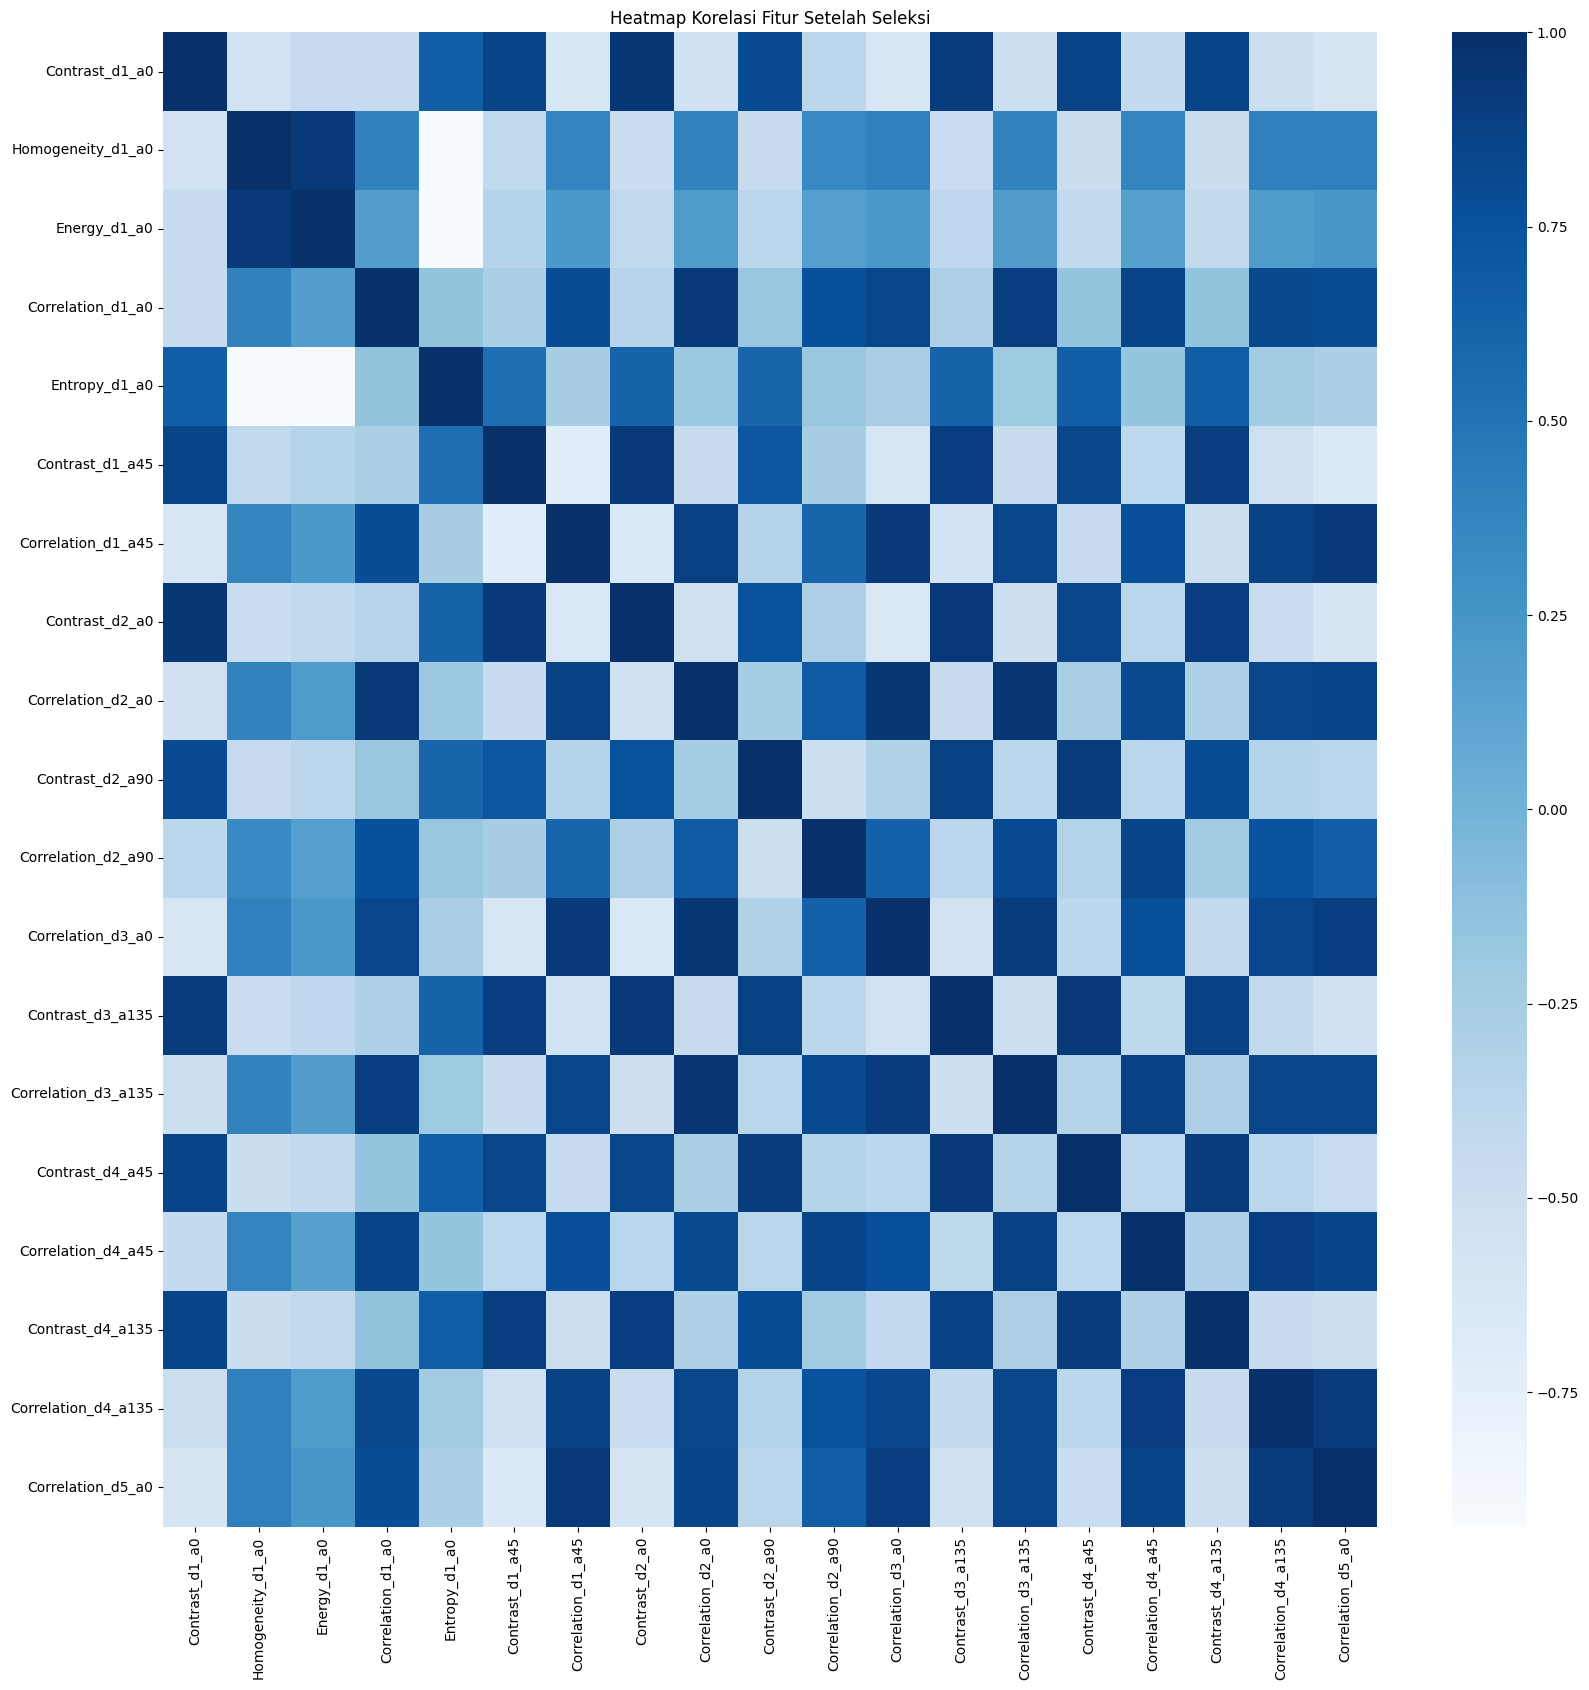

In [14]:
correlation_matrix = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if abs(correlation_matrix.iloc[i, j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Jumlah fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}")
print(f"Jumlah fitur setelah seleksi: {len(select)}")

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=False, cmap='Blues')
plt.title('Heatmap Korelasi Fitur Setelah Seleksi')
plt.tight_layout()
plt.show()

SPLITTING DATA

In [15]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (136, 19)
X_test shape:  (34, 19)


FEATURE NORMALIZATION

In [16]:
train_mean = X_train.mean()
train_std  = X_train.std()

X_train = (X_train - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

print("Normalisasi selesai.")

Normalisasi selesai.


MODELING & DEFINE MODEL

In [17]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'Recall   : {recall_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred, average="weighted"):.4f}')

rf  = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

TRAIN RANDOM FOREST CLASSIFIER

In [18]:
rf.fit(X_train, y_train)

print("------Training Set------")
generateClassificationReport(y_train, rf.predict(X_train))

print("\n------Testing Set------")
generateClassificationReport(y_test, rf.predict(X_test))

------Training Set------
              precision    recall  f1-score   support

      defect       1.00      0.98      0.99        65
  non_defect       0.99      1.00      0.99        71

    accuracy                           0.99       136
   macro avg       0.99      0.99      0.99       136
weighted avg       0.99      0.99      0.99       136

Accuracy : 0.9926
Precision: 0.9927
Recall   : 0.9926
F1-Score : 0.9926

------Testing Set------
              precision    recall  f1-score   support

      defect       0.95      0.90      0.92        20
  non_defect       0.87      0.93      0.90        14

    accuracy                           0.91        34
   macro avg       0.91      0.91      0.91        34
weighted avg       0.91      0.91      0.91        34

Accuracy : 0.9118
Precision: 0.9141
Recall   : 0.9118
F1-Score : 0.9122


TRAIN SVM CLASSIFIER

In [19]:
svm.fit(X_train, y_train)

print("------Training Set------")
generateClassificationReport(y_train, svm.predict(X_train))

print("\n------Testing Set------")
generateClassificationReport(y_test, svm.predict(X_test))

------Training Set------
              precision    recall  f1-score   support

      defect       0.91      0.95      0.93        65
  non_defect       0.96      0.92      0.94        71

    accuracy                           0.93       136
   macro avg       0.93      0.93      0.93       136
weighted avg       0.93      0.93      0.93       136

Accuracy : 0.9338
Precision: 0.9348
Recall   : 0.9338
F1-Score : 0.9339

------Testing Set------
              precision    recall  f1-score   support

      defect       1.00      0.90      0.95        20
  non_defect       0.88      1.00      0.93        14

    accuracy                           0.94        34
   macro avg       0.94      0.95      0.94        34
weighted avg       0.95      0.94      0.94        34

Accuracy : 0.9412
Precision: 0.9485
Recall   : 0.9412
F1-Score : 0.9416


TRAIN KNN CLASSIFIER

In [20]:
knn.fit(X_train, y_train)

print("------Training Set------")
generateClassificationReport(y_train, knn.predict(X_train))

print("\n------Testing Set------")
generateClassificationReport(y_test, knn.predict(X_test))

------Training Set------
              precision    recall  f1-score   support

      defect       0.97      0.89      0.93        65
  non_defect       0.91      0.97      0.94        71

    accuracy                           0.93       136
   macro avg       0.94      0.93      0.93       136
weighted avg       0.94      0.93      0.93       136

Accuracy : 0.9338
Precision: 0.9360
Recall   : 0.9338
F1-Score : 0.9336

------Testing Set------
              precision    recall  f1-score   support

      defect       1.00      0.85      0.92        20
  non_defect       0.82      1.00      0.90        14

    accuracy                           0.91        34
   macro avg       0.91      0.93      0.91        34
weighted avg       0.93      0.91      0.91        34

Accuracy : 0.9118
Precision: 0.9273
Recall   : 0.9118
F1-Score : 0.9125


EVALUATION WITH CONFUSION MATRIX

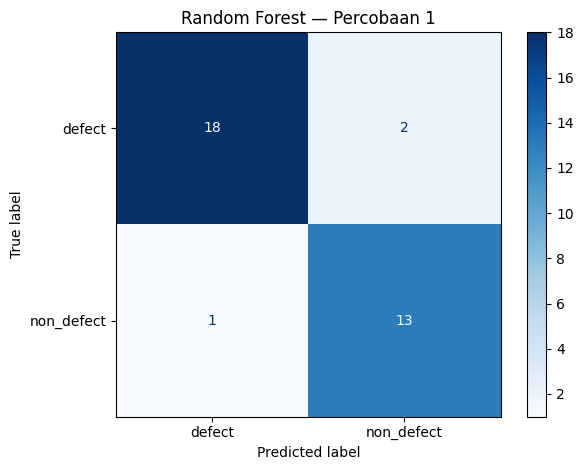

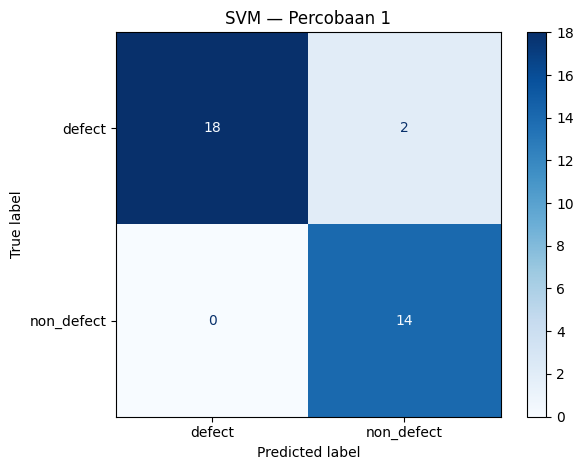

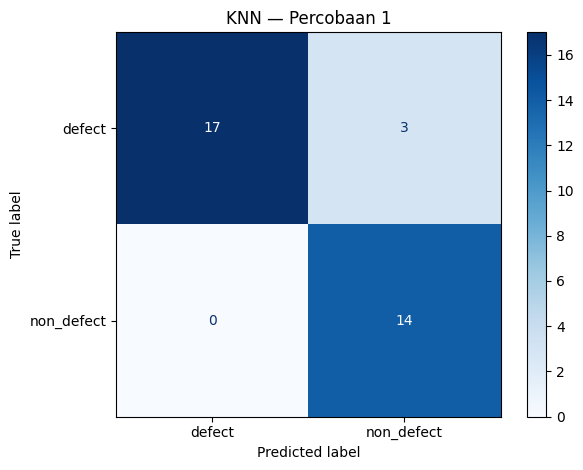

In [21]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest — Percobaan 1")
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM — Percobaan 1")
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN — Percobaan 1")

Pada percobaan 1, ketiga model menunjukkan performa yang cukup baik meskipun preprocessing yang digunakan masih minimal (hanya Resize dan Grayscale). Random Forest mencapai akurasi testing sebesar 0.9118, SVM sebesar 0.9412, dan KNN sebesar 0.9118. SVM menunjukkan performa terbaik pada data testing dengan F1-Score 0.9416.

Dari confusion matrix, ketiga model lebih sering salah mengklasifikasikan citra defect sebagai non_defect (false negative), sedangkan tidak ada atau sangat sedikit citra non_defect yang salah diklasifikasikan sebagai defect. Hal ini dapat dilihat pada SVM dan KNN yang berhasil mengklasifikasikan seluruh citra non_defect dengan benar (recall 1.00), namun masih terdapat 2-3 citra defect yang terklasifikasi salah.

Selain itu, terdapat perbedaan akurasi yang cukup besar antara training set dan testing set pada Random Forest (training 0.9926 vs testing 0.9118), yang mengindikasikan adanya overfitting. SVM dan KNN menunjukkan gap yang lebih kecil antara training dan testing, sehingga generalisasinya lebih stabil.

Secara umum, hasil menunjukkan bahwa fitur GLCM dari citra grayscale tanpa preprocessing tambahan sudah cukup mampu membedakan tekstur kain defect dan non_defect, namun masih harus ditingkatkan terutama pada kesalahan klasifikasi pada citra defect.